# Multi-class Inference with CLIP-EBC
This notebook demonstrates how to load a multi-class trained CLIP-EBC model and perform inference.

In [1]:
import os
import sys
import torch
from torch.utils.data import DataLoader
from torchvision.transforms.functional import normalize, to_pil_image
import torch.nn.functional as F
import matplotlib.pyplot as plt
import numpy as np

parent_dir = os.path.abspath(os.path.join(os.getcwd(), os.pardir))
sys.path.insert(0, parent_dir)

import datasets
from models import get_model
from utils import resize_density_map

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

# Path to your checkpoint
model_info_path = os.path.join(parent_dir, "checkpoints", "demo_data", "best_mae_0.pth")

model = get_model(model_info_path)
model = model.to(device)
model.eval()
print(f"Model loaded with {model.num_classes} classes.")

c:\Users\QUAN\AppData\Local\Programs\Python\Python312\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


Model loaded with 2 classes.


In [2]:
dataset_name = "demo_data"
split = "train"
num_classes = model.num_classes

dataset = datasets.Crowd(dataset=dataset_name, split=split, sigma=8, return_filename=True, num_classes=num_classes)
dataloader = DataLoader(dataset, batch_size=1, shuffle=False, num_workers=0, collate_fn=datasets.collate_fn)
data_iter = iter(dataloader)

mean = (0.48145466, 0.4578275, 0.40821073)
std = (0.26862954, 0.26130258, 0.27577711)
alpha = 0.6

Using demo_data
Using custom dataset 'demo_data'. Skipping sanity checks.
Found 374 images and 374 labels for the 'train' split.


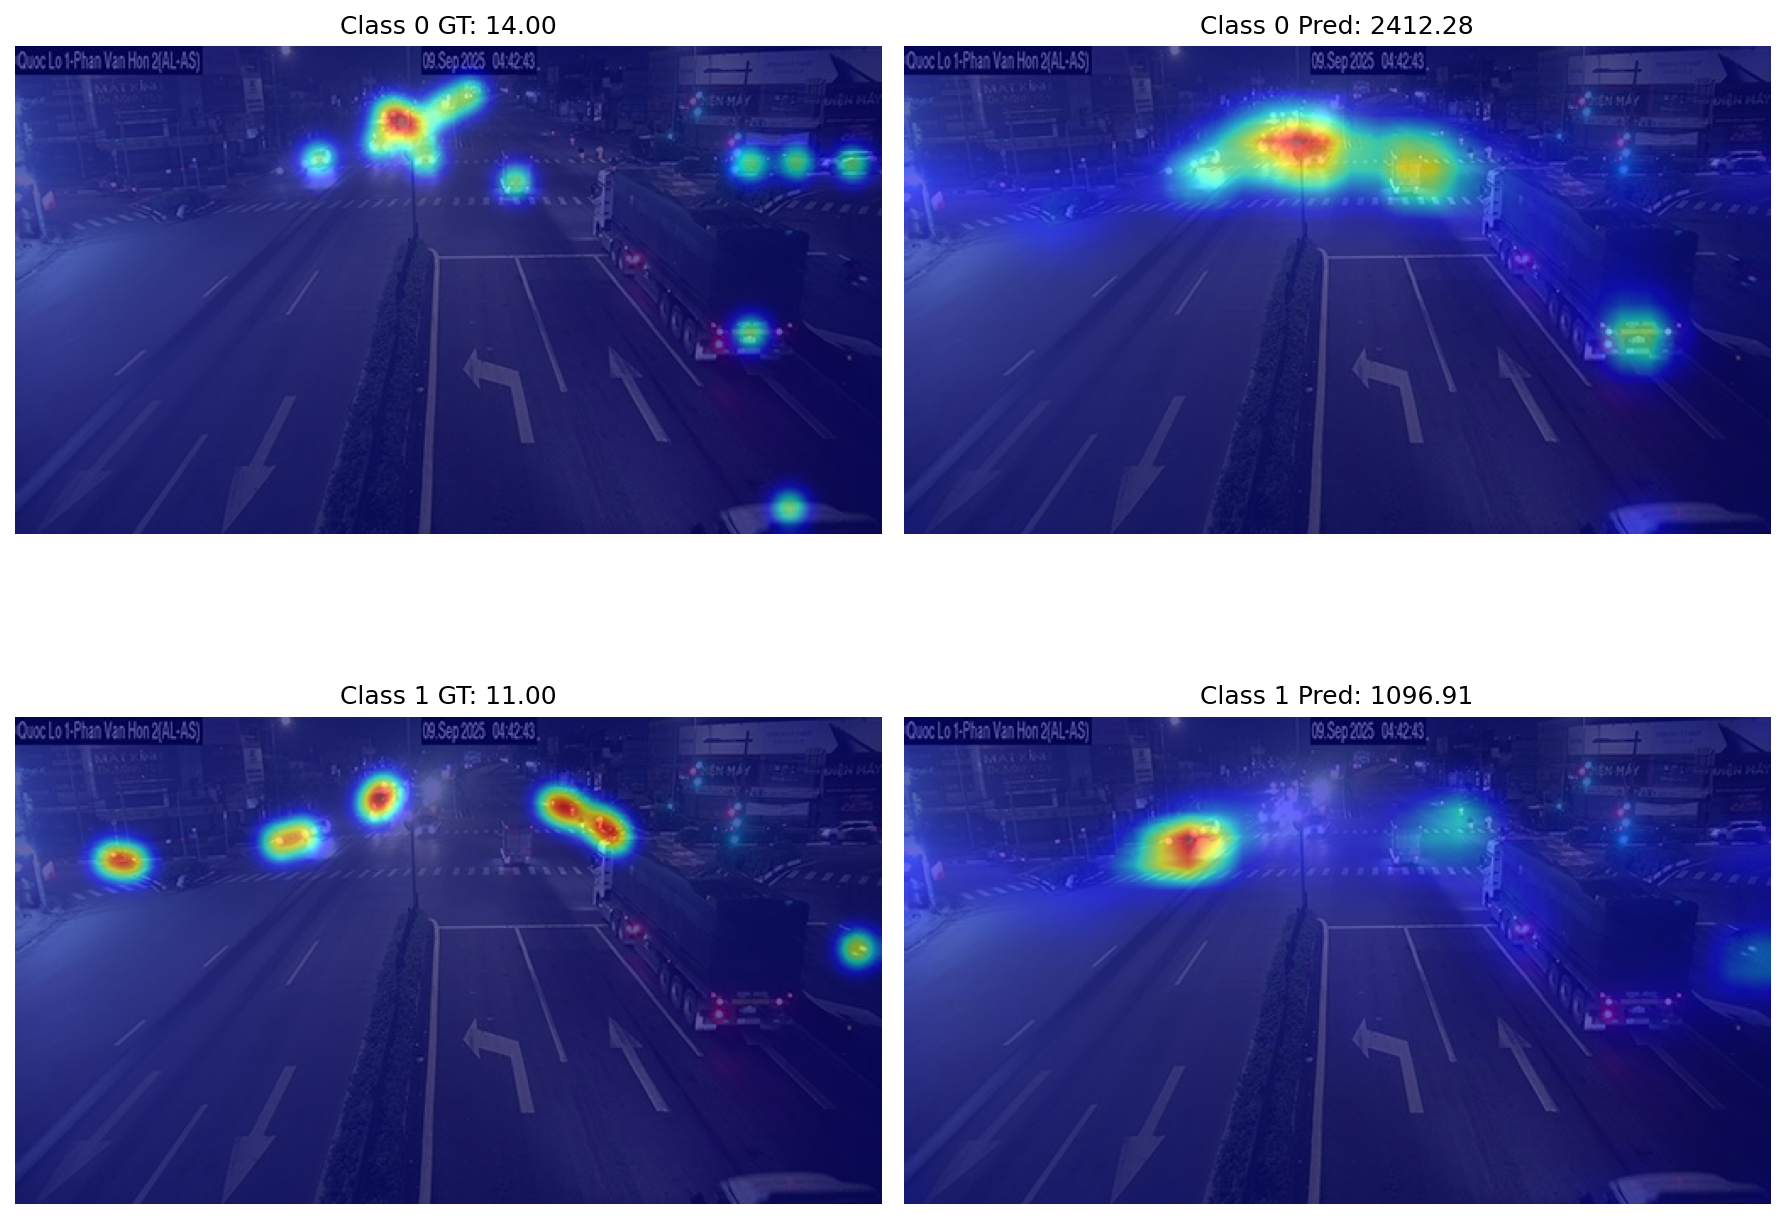

Image: 1.jpg
Class 0 -> GT: 14.00, Pred: 2412.28, Error: 2398.28
Class 1 -> GT: 11.00, Pred: 1096.91, Error: 1085.91


In [3]:
from skimage.feature import peak_local_max

# Get one sample
image, points, gt_density, image_name = next(data_iter)
image_height, image_width = image.shape[-2:]
image = image.to(device)

with torch.no_grad():
    # Inference
    # pred_den_map shape: (1, num_classes, H_block, W_block)
    pred_den_map = model(image)
    
    # Upsample to original image size
    pred_den_map = F.interpolate(pred_den_map, size=(image_height, image_width), mode="bilinear", align_corners=False)
    
    # Calculate counts per class
    pred_counts = pred_den_map.sum(dim=(2, 3)).squeeze().cpu().numpy()
    gt_counts = gt_density.sum(dim=(2, 3)).squeeze().cpu().numpy()

# Unnormalize image for visualization
vis_image = normalize(image.clone(), mean=(0., 0., 0.), std=(1. / std[0], 1. / std[1], 1. / std[2]))
vis_image = normalize(vis_image, mean=(-mean[0], -mean[1], -mean[2]), std=(1., 1., 1.))
vis_image = to_pil_image(vis_image.squeeze(0))

# Visualization
fig, axes = plt.subplots(num_classes, 2, figsize=(12, 5 * num_classes), dpi=150)
if num_classes == 1:
    axes = np.expand_dims(axes, axis=0)

for c in range(num_classes):
    # GT
    axes[c, 0].imshow(vis_image)
    axes[c, 0].imshow(gt_density[0, c].cpu().numpy(), cmap="jet", alpha=alpha)
    axes[c, 0].set_title(f"Class {c} GT: {gt_counts[c]:.2f}")
    axes[c, 0].axis("off")
    
    # Pred
    axes[c, 1].imshow(vis_image)
    axes[c, 1].imshow(pred_den_map[0, c].cpu().numpy(), cmap="jet", alpha=alpha)
    axes[c, 1].set_title(f"Class {c} Pred: {pred_counts[c]:.2f}")
    axes[c, 1].axis("off")

plt.tight_layout()
plt.show()

print(f"Image: {image_name[0]}")
for c in range(num_classes):
    print(f"Class {c} -> GT: {gt_counts[c]:.2f}, Pred: {pred_counts[c]:.2f}, Error: {abs(gt_counts[c] - pred_counts[c]):.2f}")
